In [2]:
%reset
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [3]:
# Definitions and Set Variables

alpha = 10.0      # Maximum Transcription Rate
alpha0 = 0.01     # Basal Transcription Rate
beta = 5.0        # Protein Degradation
n = 2.0           # Hill Coefficient

def repressilator(t, y):
    
    # unpack y = [m1, m2, m3, p1, p2, p3]
    m1, m2, m3, p1, p2, p3 = y

    # mRNA Dynamics
    dm1_dt = -m1 + alpha / (1 + p3**n) + alpha0
    dm2_dt = -m2 + alpha / (1 + p1**n) + alpha0
    dm3_dt = -m3 + alpha / (1 + p2**n) + alpha0

    # Protein Dynamics
    dp1_dt = -beta * (p1 - m1)
    dp2_dt = -beta * (p2 - m2)
    dp3_dt = -beta * (p3 - m3)

    deltas = [dm1_dt, dm2_dt, dm3_dt, dp1_dt, dp2_dt, dp3_dt]
    
    return deltas

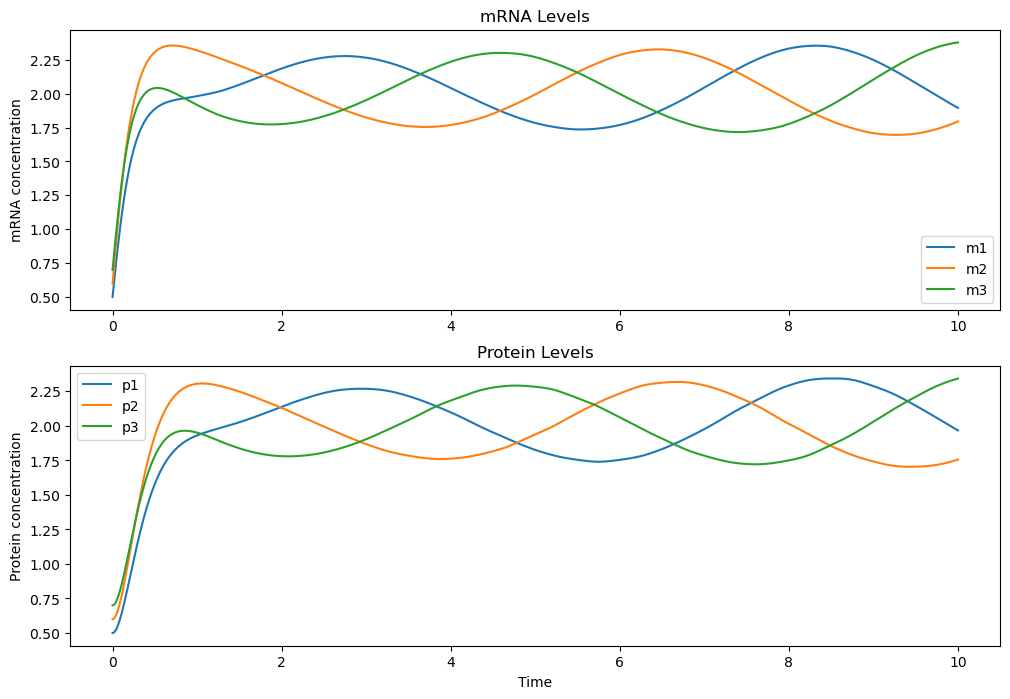

In [4]:
y0 = [0.5, 0.6, 0.7, 0.5, 0.6, 0.7]  # [m1, m2, m3, p1, p2, p3]
t = np.linspace(0,10,1000)

# --- Solve the ODE system ---
solution = solve_ivp(repressilator, [t[0], t[-1]], y0, t_eval=t)

# --- Plot the results ---
plt.figure(figsize=(12, 8))

# Plot mRNA dynamics
plt.subplot(2, 1, 1)
plt.plot(solution.t, solution.y[0], label="m1")
plt.plot(solution.t, solution.y[1], label="m2")
plt.plot(solution.t, solution.y[2], label="m3")
plt.ylabel("mRNA concentration")
plt.title("mRNA Levels")
plt.legend()

# Plot protein dynamics
plt.subplot(2, 1, 2)
plt.plot(solution.t, solution.y[3], label="p1")
plt.plot(solution.t, solution.y[4], label="p2")
plt.plot(solution.t, solution.y[5], label="p3")
plt.xlabel("Time")
plt.ylabel("Protein concentration")
plt.title("Protein Levels")
plt.legend()

plt.show()